In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("real_estate.csv")
print(df.head())
print(df.head())

   property_id          address           city state  zip_code  property_type  \
0            1   123 Oak Street    Los Angeles    CA     90001  Single Family   
1            2  456 Pine Avenue  San Francisco    CA     94102          Condo   
2            3  789 Maple Drive        Seattle    WA     98101  Single Family   
3            4   321 Cedar Lane         Austin    TX     78701      Townhouse   
4            5   654 Birch Road         Denver    CO     80202  Single Family   

   bedrooms  bathrooms  sqft  lot_size  ...  pool  garage  basement  stories  \
0         4        3.0  2500      0.25  ...   Yes     Yes        No        2   
1         2        2.0  1200      0.00  ...    No      No        No        1   
2         3        2.0  1800      0.15  ...    No     Yes       Yes        2   
3         3        2.5  1650      0.08  ...    No     Yes        No        3   
4         5        4.0  3200      0.35  ...   Yes     Yes       Yes        2   

   condition neighborhood_rating

In [2]:
#price statistic by Property Type

property_type = df.groupby('property_type')[['property_type','list_price','sale_price']]

property_type.head(10)




,property_type,list_price,sale_price
0,Single Family,850000,825000
1,Condo,720000,735000
2,Single Family,650000,640000
3,Townhouse,480000,495000
4,Single Family,920000,890000
5,Single Family,425000,420000
6,Condo,385000,380000
7,Condo,580000,595000
8,Townhouse,350000,345000
9,Single Family,1150000,1120000


In [3]:
#Price Difference Analysis
df['price_diff'] = df['list_price'] - df['sale_price']

df[['property_type','list_price','sale_price','price_diff']]


,property_type,list_price,sale_price,price_diff
0,Single Family,850000,825000,25000
1,Condo,720000,735000,-15000
2,Single Family,650000,640000,10000
3,Townhouse,480000,495000,-15000
4,Single Family,920000,890000,30000
5,Single Family,425000,420000,5000
6,Condo,385000,380000,5000
7,Condo,580000,595000,-15000
8,Townhouse,350000,345000,5000
9,Single Family,1150000,1120000,30000


In [4]:


# Load the dataset
df = pd.read_csv('real_estate.csv')

# Calculate commission earned for each sale
df['commission_earned'] = df['sale_price'] * df['agent_commission']

# Agent Performance Analysis
agent_performance = df.groupby('agent_name').agg({
    'property_id': 'count',                    # Total number of sales
    'sale_price': 'sum',                       # Total sales volume
    'commission_earned': 'mean',               # Average commission earned
    'days_on_market': 'mean'                   # Average days on market
}).rename(columns={
    'property_id': 'total_sales',
    'sale_price': 'total_sales_volume',
    'commission_earned': 'avg_commission',
    'days_on_market': 'avg_days_on_market'
})

# Sort by total sales volume descending
agent_performance = agent_performance.sort_values('total_sales_volume', ascending=False)

# Round for better readability
agent_performance['avg_commission'] = agent_performance['avg_commission'].round(2)
agent_performance['avg_days_on_market'] = agent_performance['avg_days_on_market'].round(1)

print(agent_performance)


                 total_sales  total_sales_volume  avg_commission  \
agent_name                                                         
Emily Davis                8             4675000        16316.25   
Sarah Johnson              8             3990000        14363.75   
Michael Chen               5             3060000        13355.00   
Robert Martinez            8             2990000         9729.38   
Jessica Brown              7             2780000        11005.00   
Amanda Wilson              7             2715000        10743.57   
David Lee                  7             2575000        10857.14   

                 avg_days_on_market  
agent_name                           
Emily Davis                    44.1  
Sarah Johnson                  46.1  
Michael Chen                   17.0  
Robert Martinez                23.9  
Jessica Brown                  39.4  
Amanda Wilson                  32.9  
David Lee                      41.7  


<Axes: xlabel='property_type'>

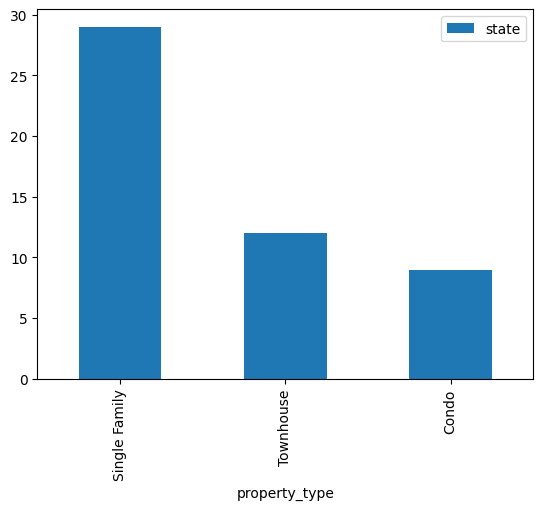

In [5]:
state_wise_property_distribution =(
    df.groupby('property_type')
    .agg({'state':'count'})
    .sort_values(by='state',ascending=False)

)

state_wise_property_distribution.plot(kind='bar')





Property Age and Condition

In [12]:
current_year = 2025


df['property_age'] = current_year - df['year_built']

In [13]:
df.head(1)

,property_id,address,city,state,zip_code,property_type,bedrooms,bathrooms,sqft,lot_size,...,condition,neighborhood_rating,school_rating,crime_rate,latitude,longitude,commission_earned,price_per_sqft,is_outlier,property_age
0,1,123 Oak Street,Los Angeles,CA,90001,Single Family,4,3.0,2500,0.25,...,Excellent,8.5,9.0,2.3,34.0522,-118.2437,24750.0,330.0,False,30


In [14]:
condition_map = {
    'Poor':1,
    "Fair":2,
    "Good":3,
    "Exellent":4
}

df['condition_score'] = df['condition'].map(condition_map)

In [16]:
df['age_group'] = pd.cut(
    df['property_age'],
    bins=[0,10,20,30,40,50,60,70,80,90,100],
    labels=['0-10','11-20','21-30','31-40','41-50','51-60','61-70','71-80','81-90','91-100']
)

df.groupby('age_group')['condition_score'].mean()

C:\Users\francis\AppData\Local\Temp\ipykernel_22880\384195643.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['condition_score'].mean()


age_group
0-10      3.000000
11-20     3.000000
21-30     2.727273
31-40     2.000000
41-50     3.000000
51-60     3.000000
61-70          NaN
71-80          NaN
81-90          NaN
91-100    2.000000
Name: condition_score, dtype: float64

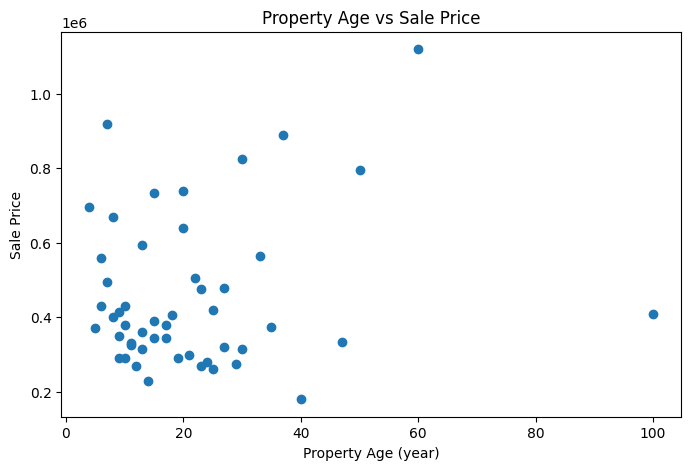

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(df['property_age'],df['sale_price'])
plt.xlabel('Property Age (year)')
plt.ylabel('Sale Price')
plt.title('Property Age vs Sale Price')
plt.show()

1 Amenities Impact on Price Medium grouped bar chart

In [27]:
amenities = ['pool', 'garage', 'basement', 'gym']

summary = {}

for amenity in amenities:
    if amenity in df.columns:   
        summary[amenity] = df.groupby(amenity)['sale_price'].mean()

amenity_price_df = pd.DataFrame(summary)
amenity_price_df


,pool,garage,basement
No,425000.000000,463750.000000,458548.387097
Yes,515294.117647,451911.764706,451052.631579


<Axes: title={'center': 'Average Sale Price by Amenity'}>

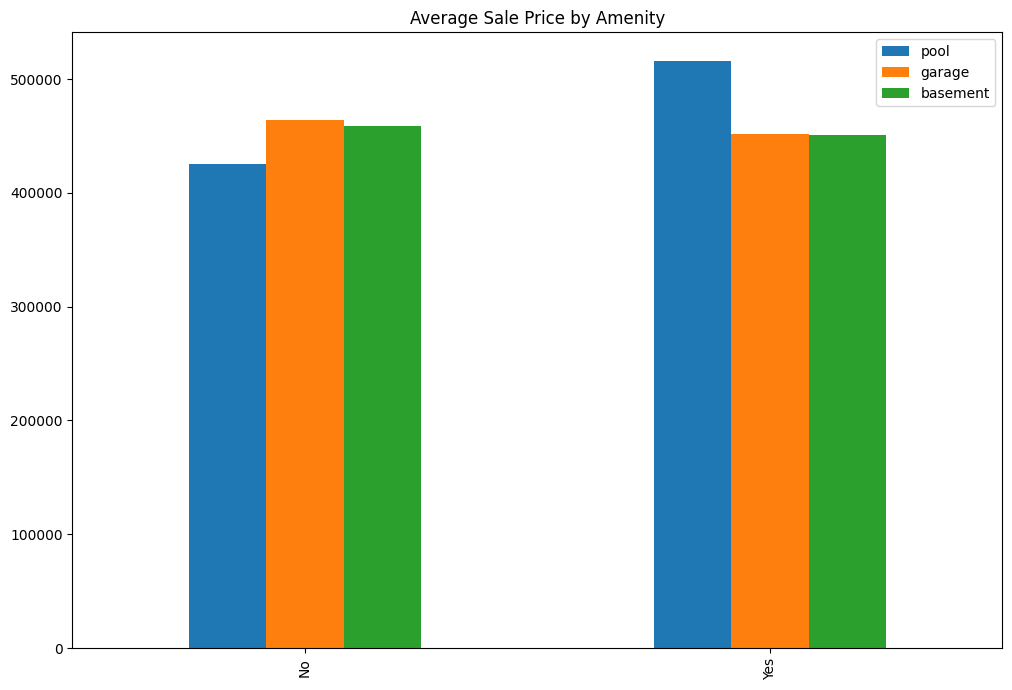

In [29]:
amenity_price_df.plot(kind='bar', title='Average Sale Price by Amenity', figsize=(12,8))

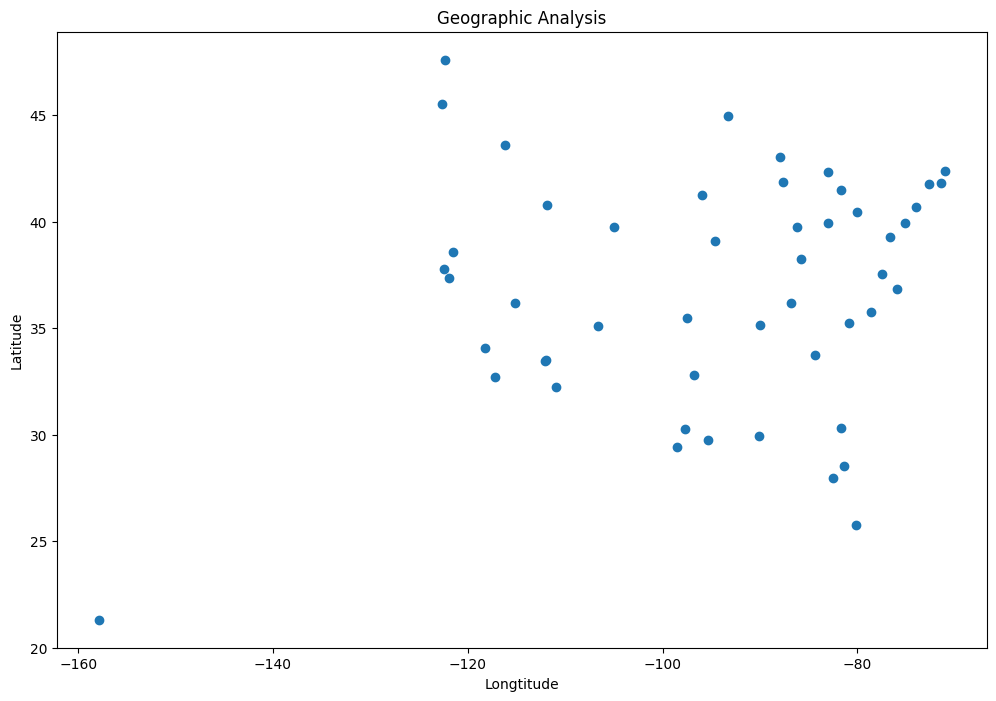

In [32]:
plt.figure(figsize=(12,8))
plt.scatter(df['longitude'],df['latitude'])
plt.xlabel('Longtitude')
plt.ylabel('Latitude')
plt.title('Geographic Analysis')
plt.show()




In [34]:
df['sale_date'] = pd.to_datetime(df['sale_date'])

monthly_summary = (
    df.set_index('sale_date')
    .resample('M')
    .agg(
        total_sales = ('sale_price','count'),
        avg_price = ('sale_price','mean')
    )
)

monthly_summary

C:\Users\francis\AppData\Local\Temp\ipykernel_22880\4104546121.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


,total_sales,avg_price
sale_date,,
2024-02-29,2,812500.000000
2024-03-31,48,440833.333333


13	Neighborhood Rating Impact	Hard	quartiles, box plots

In [ ]:
df['neighborhood_rating'] = pd.to_numeric(df['neighborhood_rating'],errors='coerce')
df = df.dropna(subset=['neighborhood_rating', 'sale_price'])


#create quanrtile from Neighborhood rating

df['rating_quantile'] = pd.qcut(
    df['neighborhood_rating'],
    q=4,
    labels=['Q1 (lowest)','Q2','Q3','Q4 (Highest)']
)



In [44]:
plt.figure(figsize=(12,8))

df.boxplot(
    column='sale_price',
    by='rating_quantile'
)

plt.xlabel('Neighborhood rating quantile')
plt.ylabel('Sale Price')

plt.title('Neighborhood rating Impact on Sale Price')
plt.subptitle('')
plt.show()

KeyError: 'rating_quantile'

<Figure size 1200x800 with 0 Axes>